# Testing Data Retrieval and Database Building from WQP
Using WQP's webservice APIs

In [1]:
# %pip -q install pandas

In [1]:
import requests
import pandas as pd
from io import StringIO

url = "https://www.waterqualitydata.us/data/Result/search"
# bbox = "-88.7,41.3,-84.4,46.4"  # lake michigan rough bounding box
# bbox = "-82.36,27.84,-82.25,27.89"  # riverview, FL (alafia river)
# bbox = "-95.55,29.73,-95.28,29.78"  # houston, TX
# bbox = "-87.75,41.86,-87.58,41.95"
bbox = "-112.15,33.40,-111.95,33.50"  # pheonix

params = [
    # ("countrycode", "LE"),
    ("bBox", bbox),
    ("dataProfile", "resultPhysChem"),
    ("providers", "NWIS"),
    ("providers", "STORET"),
    ("mimeType", "csv"),
    ("zip", "no"),
    ("startDateLo", "01-01-2010"),
    ("startDateHi", "12-31-2020"),
]

r = requests.get(url, params=params, timeout=180)
print("STATUS:", r.status_code)
print("URL:", r.url)
print("Warning:", r.headers.get("Warning"))
print("BODY preview:", r.text[:300])

r.raise_for_status()
df = pd.read_csv(StringIO(r.text))
df.head()


STATUS: 200
URL: https://www.waterqualitydata.us/data/Result/search?bBox=-112.15%2C33.40%2C-111.95%2C33.50&dataProfile=resultPhysChem&providers=NWIS&providers=STORET&mimeType=csv&zip=no&startDateLo=01-01-2010&startDateHi=12-31-2020
BODY preview: OrganizationIdentifier,OrganizationFormalName,ActivityIdentifier,ActivityTypeCode,ActivityMediaName,ActivityMediaSubdivisionName,ActivityStartDate,ActivityStartTime/Time,ActivityStartTime/TimeZoneCode,ActivityEndDate,ActivityEndTime/Time,ActivityEndTime/TimeZoneCode,ActivityRelativeDepthName,Activit


C:\Users\kcui2\AppData\Local\Temp\ipykernel_17132\1420030113.py:31: DtypeWarning: Columns (20,27,28,38,43,45,48,49,50,59,70,72,73) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(StringIO(r.text))


,OrganizationIdentifier,OrganizationFormalName,ActivityIdentifier,ActivityTypeCode,ActivityMediaName,ActivityMediaSubdivisionName,ActivityStartDate,ActivityStartTime/Time,ActivityStartTime/TimeZoneCode,ActivityEndDate,...,LaboratoryName,AnalysisStartDate,ResultLaboratoryCommentText,ResultDetectionQuantitationLimitUrl,DetectionQuantitationLimitTypeName,DetectionQuantitationLimitMeasure/MeasureValue,DetectionQuantitationLimitMeasure/MeasureUnitCode,LabSamplePreparationUrl,LastUpdated,ProviderName
0,AZDEQ_WPD,AZDEQ_WPD,AZDEQ_WPD-GW-157332.CHEM,Sample-Routine,Other,NaN,2016-11-01,10:37:00,EST,NaN,...,TEST AMERICA LABORATORY - OTHER,2016-11-04,NaN,https://www.waterqualitydata.us/data/providers...,Laboratory Reporting Level,0.5,ug/L,NaN,2017-11-03T10:17:07,STORET
1,AZDEQ_WPD,AZDEQ_WPD,AZDEQ_WPD-GW-157172.CHEM,Sample-Routine,Other,NaN,2016-10-28,06:55:00,EST,NaN,...,TEST AMERICA LABORATORY - OTHER,2016-11-03,NaN,https://www.waterqualitydata.us/data/providers...,Laboratory Reporting Level,0.5,ug/L,NaN,2017-11-03T10:07:03,STORET
2,AZDEQ_WPD,AZDEQ_WPD,AZDEQ_WPD-GW-155547.CHEM,Sample-Routine,Water,Groundwater,2016-08-25,01:32:00,EST,NaN,...,TEST AMERICA LABORATORY - PHOENIX,2016-08-29,NaN,https://www.waterqualitydata.us/data/providers...,Laboratory Reporting Level,2.0,ug/L,NaN,2019-10-07T11:01:28,STORET
3,AZDEQ_WPD,AZDEQ_WPD,AZDEQ_WPD-GW-156869.CHEM,Sample-Routine,Other,NaN,2016-09-12,02:10:00,EST,NaN,...,TEST AMERICA LABORATORY - PHOENIX,2016-09-15,NaN,https://www.waterqualitydata.us/data/providers...,Laboratory Reporting Level,1.1,ug/L,NaN,2017-11-03T10:14:15,STORET
4,AZDEQ_WPD,AZDEQ_WPD,AZDEQ_WPD-AB16439.CHEM,Sample-Routine,Other,NaN,2016-02-23,09:51:00,EST,NaN,...,MONTGOMERY WATSON LABORATORIES,NaN,NaN,https://www.waterqualitydata.us/data/providers...,Laboratory Reporting Level,0.5,ug/L,NaN,2019-02-07T09:12:18,STORET


In [2]:
df.shape

(183955, 81)

Note: Chicago's bounding box seems to have very little data.

## Core Columns for Trend Analysis

### Time Axis (Mandatory)
- `ActivityStartDate`
- `ActivityStartTime/Time`
- `ActivityEndDate`
- `ActivityEndTime/Time`

### Location Axis (Mandatory)
- `MonitoringLocationIdentifier`

### Location Context
- `ActivityDepthHeightMeasure/MeasureValue`
- `ActivityMediaName`

### Measurement Axis (Mandatory)
- `CharacteristicName`
- `ResultMeasureValue`
- `ResultMeasure/MeasureUnitCode`

---

## Quality Control Columns
- `ResultStatusIdentifier`
- `MeasureQualifierCode`
- `DetectionQuantitationLimitMeasure/MeasureValue`
- `ResultDetectionConditionText`

---

## Optional but Useful Columns
- `ProjectIdentifier`
- `ResultAnalyticalMethod/MethodName`
- `DataProvider`
- `ActivityDepthHeightMeasure/MeasureUnitCode`


Other potential columns:
- `ResultSampleFractionText`
- `ResultStatusIdentifier`
- `ResultAnalyticalMethod/MethodIdentifier`
- `ResultAnalyticalMethod/MethodIdentifierContext`
- `ResultAnalyticalMethod/MethodName`

- `AnalysisStartDate`
- `LastUpdated`

In [3]:
# filter only necessary columns
columns_to_keep = [
    "ActivityStartDate",
    "ActivityStartTime/Time",
    "ActivityEndDate",
    "ActivityEndTime/Time",
    "MonitoringLocationIdentifier",
    "ActivityDepthHeightMeasure/MeasureValue",
    "ActivityMediaName",
    "CharacteristicName",
    "ResultMeasureValue",
    "ResultMeasure/MeasureUnitCode",
    "ResultStatusIdentifier",
    "MeasureQualifierCode",
    "DetectionQuantitationLimitMeasure/MeasureValue",
    "ResultDetectionConditionText",
    "ProjectIdentifier",
    "ResultAnalyticalMethod/MethodName",
    "ProviderName",
    "ActivityDepthHeightMeasure/MeasureUnitCode",
]

df_target = df[columns_to_keep]
df_target.head(10), df_target.shape


(  ActivityStartDate ActivityStartTime/Time  ActivityEndDate  \
 0        2016-11-01               10:37:00              NaN   
 1        2016-10-28               06:55:00              NaN   
 2        2016-08-25               01:32:00              NaN   
 3        2016-09-12               02:10:00              NaN   
 4        2016-02-23               09:51:00              NaN   
 5        2016-08-25               01:32:00              NaN   
 6        2016-02-23               09:51:00              NaN   
 7        2016-09-08               02:07:00              NaN   
 8        2016-02-22               10:01:00              NaN   
 9        2016-08-24               12:45:00              NaN   
 
    ActivityEndTime/Time MonitoringLocationIdentifier  \
 0                   NaN              AZDEQ_WPD-54997   
 1                   NaN              AZDEQ_WPD-47502   
 2                   NaN              AZDEQ_WPD-59345   
 3                   NaN              AZDEQ_WPD-54644   
 4       

In [5]:
# %pip install matplotlib

num rows after cleaning: 12123
unique characteristics: 249
Plotting characteristic: pH | unit: std units


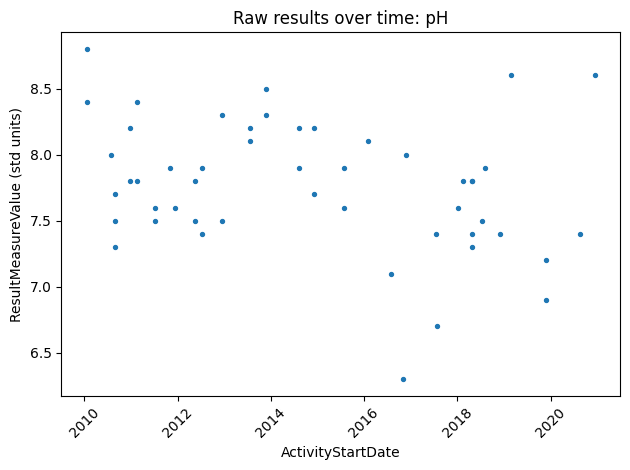

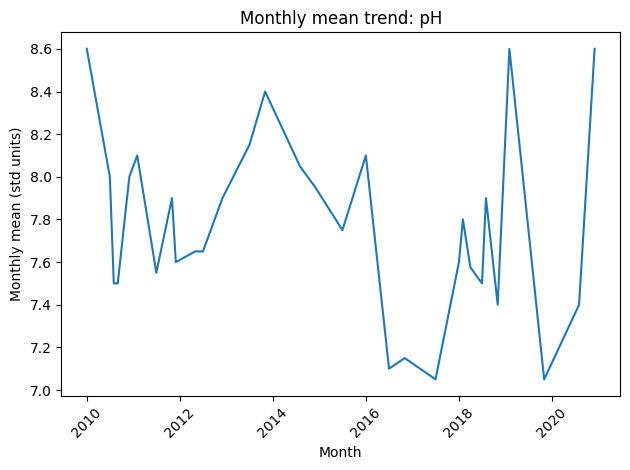

C:\Users\kcui2\AppData\Local\Temp\ipykernel_17132\881363518.py:75: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=False)


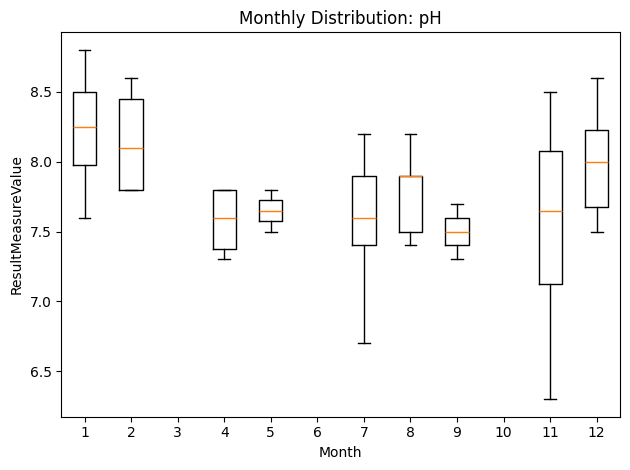

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

data = df_target.copy()

# basic cleaning
data["ActivityStartDate"] = pd.to_datetime(data["ActivityStartDate"], errors="coerce")

# ensure measurements are numeric values
data["ResultMeasureValue"] = pd.to_numeric(data["ResultMeasureValue"], errors="coerce")

# (optional) only keep data labeled as "accepted," note that this removes majority of data
# data = data[data["ResultStatusIdentifier"].astype(str).str.lower().eq("accepted")]

# drop rows missing critical fields
data = data.dropna(subset=["ActivityStartDate", "CharacteristicName", "ResultMeasureValue"])

print("num rows after cleaning:", len(data))
print("unique characteristics:", data["CharacteristicName"].nunique())

# pick a characteristic
# char = data["CharacteristicName"].value_counts().index[2]  # change the index for a common measurement
# or
char = 'pH'  # hardcode

dchar = data[data["CharacteristicName"] == char].copy()

# multiple units exist --> pick the most common unit to avoid unit-mixing in plots
if "ResultMeasure/MeasureUnitCode" in dchar.columns:
    unit = dchar["ResultMeasure/MeasureUnitCode"].value_counts().index[0]
    dchar = dchar[dchar["ResultMeasure/MeasureUnitCode"] == unit]
else:
    unit = None

print("Plotting characteristic:", char, "| unit:", unit)

# plot A: raw time series (all points)
plt.figure()
plt.scatter(dchar["ActivityStartDate"], dchar["ResultMeasureValue"], s=8)
plt.xlabel("ActivityStartDate")
plt.ylabel("ResultMeasureValue" + (f" ({unit})" if unit else ""))
plt.title(f"Raw results over time: {char}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# plot B: monthly average trend
monthly = (
    dchar.set_index("ActivityStartDate")["ResultMeasureValue"]
         .resample("MS")
         .mean()
         .dropna()
)

plt.figure()
plt.plot(monthly.index, monthly.values)
plt.xlabel("Month")
plt.ylabel("Monthly mean" + (f" ({unit})" if unit else ""))
plt.title(f"Monthly mean trend: {char}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# plot C: monthly boxplots (distribution by month), can be yearly when we have more data
dchar["Month"] = dchar["ActivityStartDate"].dt.month

months = list(range(1, 13))

box_data = [
    dchar.loc[dchar["Month"] == m, "ResultMeasureValue"].dropna().values
    for m in months
]

plt.figure()
plt.boxplot(box_data, labels=months, showfliers=False)
plt.xlabel("Month")
plt.ylabel("ResultMeasureValue")
plt.title(f"Monthly Distribution: {char}")
plt.tight_layout()
plt.show()


Note: Chicago's data looks incredibly sparse despite the bounding box being larger (139km^2).

In [5]:
# visualizations for multiple characteristics
def plot_wqp_characteristic_trends(
    df: pd.DataFrame,
    characteristics,
    date_col: str = "ActivityStartDate",
    char_col: str = "CharacteristicName",
    value_col: str = "ResultMeasureValue",
    unit_col: str = "ResultMeasure/MeasureUnitCode",
    only_accepted: bool = False,
    status_col: str = "ResultStatusIdentifier",
    choose_unit: str = "most_common",   # "most_common" or a specific unit string
    showfliers: bool = False,
    point_size: int = 8
):
    """
    For each characteristic in `characteristics`, plots:
      A) raw scatter over time
      B) monthly mean trend
      C) monthly boxplots (distribution by month)

    Notes:
      - Drops rows with missing date/characteristic/value
      - Coerces date/value types
      - Optionally filters to accepted results
      - If multiple units exist, can pick the most common unit to avoid mixing
    """
    # Normalize characteristics input
    if isinstance(characteristics, str):
        characteristics = [characteristics]

    data = df.copy()

    # Basic cleaning
    data[date_col] = pd.to_datetime(data[date_col], errors="coerce")
    data[value_col] = pd.to_numeric(data[value_col], errors="coerce")

    if only_accepted and status_col in data.columns:
        data = data[data[status_col].astype(str).str.lower().eq("accepted")]

    # Drop rows missing critical fields
    data = data.dropna(subset=[date_col, char_col, value_col])

    print("num rows after cleaning:", len(data))
    print("unique characteristics:", data[char_col].nunique())

    for char in characteristics:
        dchar = data[data[char_col] == char].copy()

        if dchar.empty:
            print(f"Skipping '{char}' (no rows after filtering).")
            continue

        # Unit handling
        unit = None
        if unit_col in dchar.columns:
            if choose_unit == "most_common":
                unit = dchar[unit_col].dropna().value_counts().index[0] if dchar[unit_col].notna().any() else None
                if unit is not None:
                    dchar = dchar[dchar[unit_col] == unit]
            else: 
                unit = choose_unit
                dchar = dchar[dchar[unit_col] == unit]

        if dchar.empty:
            print(f"Skipping '{char}' (no rows after unit filter).")
            continue

        print("Plotting characteristic:", char, "| unit:", unit)

        # ---- Plot A: raw time series (scatter) ----
        plt.figure(figsize=(4, 3))
        plt.scatter(dchar[date_col], dchar[value_col], s=point_size)
        plt.xlabel(date_col)
        plt.ylabel(value_col + (f" ({unit})" if unit else ""))
        plt.title(f"Raw results over time: {char}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # ---- Plot B: monthly mean trend ----
        monthly = (
            dchar.set_index(date_col)[value_col]
                .resample("MS")
                .mean()
                .dropna()
        )

        plt.figure(figsize=(4, 3))
        plt.plot(monthly.index, monthly.values)
        plt.xlabel("Month")
        plt.ylabel("Monthly mean" + (f" ({unit})" if unit else ""))
        plt.title(f"Monthly mean trend: {char}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # ---- Plot C: monthly boxplots ----
        dchar["Month"] = dchar[date_col].dt.month
        months = list(range(1, 13))

        box_data = [
            dchar.loc[dchar["Month"] == m, value_col].dropna().values
            for m in months
        ]

        plt.figure(figsize=(4, 3))
        plt.boxplot(box_data, labels=months, showfliers=showfliers)
        plt.xlabel("Month")
        plt.ylabel(value_col + (f" ({unit})" if unit else ""))
        plt.title(f"Monthly distribution: {char}")
        plt.tight_layout()
        plt.show()


num rows after cleaning: 12123
unique characteristics: 249
Plotting characteristic: pH | unit: std units


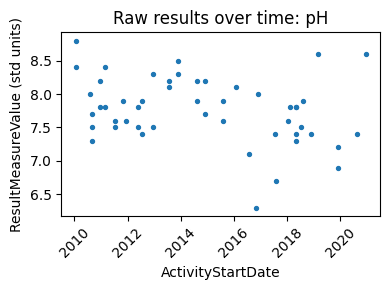

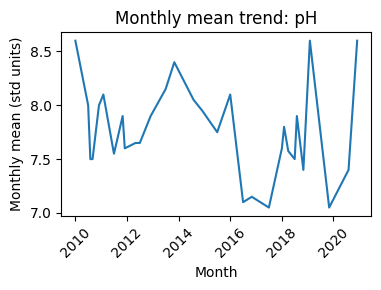

C:\Users\kcui2\AppData\Local\Temp\ipykernel_17132\3692876810.py:107: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


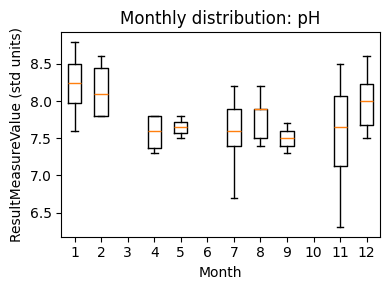

Skipping 'Temperature' (no rows after filtering).
Skipping 'water' (no rows after filtering).
Plotting characteristic: Dissolved oxygen (DO) | unit: mg/L


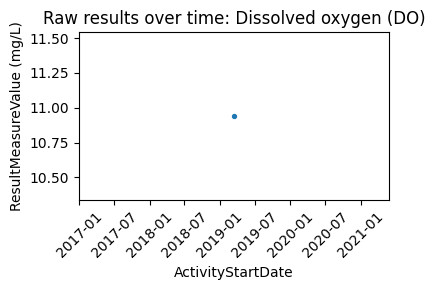

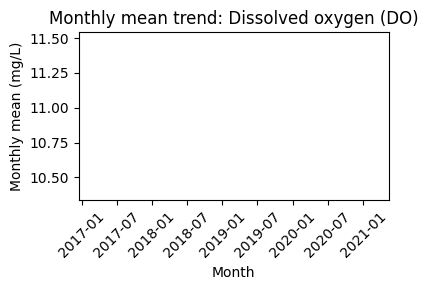

C:\Users\kcui2\AppData\Local\Temp\ipykernel_17132\3692876810.py:107: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


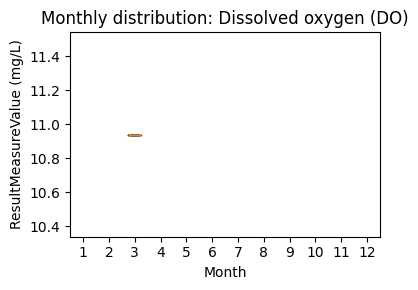

Plotting characteristic: Phosphorus | unit: mg/L


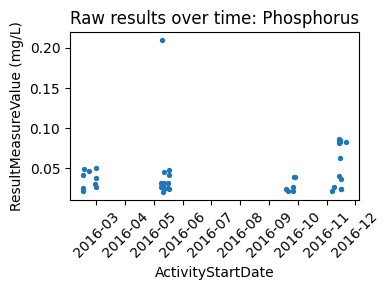

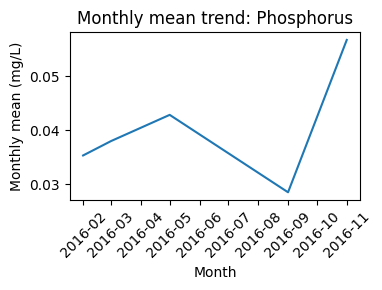

C:\Users\kcui2\AppData\Local\Temp\ipykernel_17132\3692876810.py:107: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


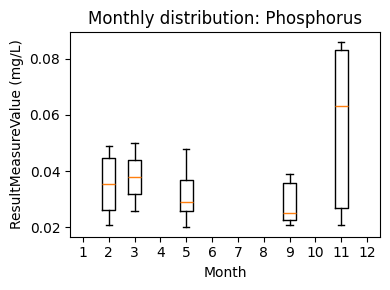

In [6]:
chars = ["pH", "Temperature", "water", "Dissolved oxygen (DO)", "Phosphorus"]
plot_wqp_characteristic_trends(df_target, chars)


Too sparse